<a href="https://colab.research.google.com/github/BioML-UGent/Advanced-AI-for-Bioinformatics/blob/main/02_optimization/02_optimization_regularization_SOLVED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PC lab 2: Training, optimization & regularization

At the end of PC lab 1, we had a digit classifier that was not trained yet: its accuracy was 10% and its loss $\ln(10) \approx 2.30$. In **part 1** of this PC lab, we train it, and look at the choices that make training work: the learning rate, the batch size, the optimizer and normalization. In **part 2**, we train on a small and noisy dataset, as is common in bioinformatics, and use regularization to keep the network from overfitting.

**Learning goals**
- Train a network with gradient descent, see how backpropagation computes the gradients, and write your own training loop
- Understand the effect of the learning rate, the batch size and the optimizer
- Know why and how to normalize the input data and the hidden layers
- Recognize overfitting in learning curves
- Apply the regularization techniques that are used in practice: early stopping and dropout (and, in the extra exercises, weight decay and data augmentation)
- Tune hyperparameters with random search

All models in this PC lab are small, so a CPU is enough.

## 0 Setup

The cells below prepare the models and data from PC lab 1: the `HyperparameterModel` class, the standardized breast cancer data, and the MNIST data loaders. There is nothing new here, so simply run them.

In [1]:
import copy
import random
import time

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader, Dataset

torch.manual_seed(42)
np.random.seed(42)

In [2]:
class HyperparameterModel(nn.Module):
    """The MLP from PC lab 1. `dropout` is now the dropout probability (0 = no dropout)."""

    def __init__(self, dimensions_from_input_to_output=(50, 40, 20, 10, 5), dropout=0.0):
        super().__init__()
        dims = dimensions_from_input_to_output

        layers = []
        # hidden layers: Linear -> ReLU (-> Dropout)
        for d_in, d_out in zip(dims[:-2], dims[1:-1]):
            layers.append(nn.Linear(d_in, d_out))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))

        # output layer, without activation
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [3]:
# Breast cancer data (PC lab 1, Exercise 1)
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = torch.from_numpy(data.data).float()
y = torch.from_numpy(data.target).long()

perm = torch.randperm(len(X))
n_train = int(0.8 * len(X))
X_train_raw, y_train = X[perm[:n_train]], y[perm[:n_train]]
X_test_raw, y_test = X[perm[n_train:]], y[perm[n_train:]]

# standardized with the statistics of the training set
mean, std = X_train_raw.mean(dim=0), X_train_raw.std(dim=0)
X_train = (X_train_raw - mean) / std
X_test = (X_test_raw - mean) / std

print(X_train.shape, X_test.shape)

torch.Size([455, 30]) torch.Size([114, 30])


In [4]:
# MNIST data (PC lab 1, section 6)
from torchvision import datasets

train_data = datasets.MNIST(root="data", train=True, download=True)
test_data = datasets.MNIST(root="data", train=False, download=True)

X_train_mnist = train_data.data.float().reshape(-1, 28 * 28) / 255
y_train_mnist = train_data.targets
X_test_mnist = test_data.data.float().reshape(-1, 28 * 28) / 255
y_test_mnist = test_data.targets

perm = torch.randperm(len(X_train_mnist))
n_train = int(0.8 * len(X_train_mnist))
X_val_mnist, y_val_mnist = X_train_mnist[perm[n_train:]], y_train_mnist[perm[n_train:]]
X_train_mnist, y_train_mnist = X_train_mnist[perm[:n_train]], y_train_mnist[perm[:n_train]]

train_loader = DataLoader(TensorDataset(X_train_mnist, y_train_mnist), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_mnist, y_val_mnist), batch_size=1000, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_mnist, y_test_mnist), batch_size=1000, shuffle=False)

print(len(X_train_mnist), len(X_val_mnist), len(X_test_mnist))

48000 12000 10000


# Part 1: Training and optimization

## 1 Gradient descent and backpropagation

Training a model means finding the weights that minimize the loss. **Gradient descent** does this by repeatedly taking a small step against the gradient of the loss:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla_{\mathbf{w}}\mathcal{L}$$

where the **learning rate** $\eta$ sets the size of the steps. We start with the simplest model from PC lab 1: the logistic regression neuron of Exercise 2, on the standardized breast cancer data (`X_train`, `y_train`, `X_test`, `y_test`, prepared in the setup). Its loss is the negative log-likelihood

$$\mathcal{L} = -\frac{1}{N}\sum_{n=1}^{N} \left[y_n \log p_n + (1 - y_n)\log(1 - p_n)\right]$$

where $p_n$ is the predicted probability for sample $n$. Its gradient has a simple closed form:

$$\nabla_{\mathbf{w}} \mathcal{L} = \frac{1}{N}\mathbf{X}^\top(\mathbf{p} - \mathbf{y}), \qquad \frac{\partial \mathcal{L}}{\partial w_0} = \frac{1}{N}\sum_{n=1}^{N} (p_n - y_n)$$

<div class="alert alert-success">

<b>EXERCISE 1: gradient descent and backpropagation</b>

a) The cell for a) trains the neuron with 100 steps of gradient descent, starting from random weights. The loss and the gradients are already computed: complete the update of the weights `w` and the bias `w0`, with learning rate `lr`. Then run the cell. Compare the train and test accuracy with the accuracy of random weights in PC lab 1.

b) <b>THINK:</b> For a network with hidden layers, deriving every gradient by hand quickly becomes impractical. **Backpropagation** computes them layer by layer, from the output back to the input. Run the cell for b), which does this by hand for a network with one hidden layer, and compares the result with the gradients that PyTorch computes with `loss.backward()`. The $\delta$'s of the hidden layer reuse the $\delta$'s of the output layer. Why does this make backpropagation efficient? (Think of computing the Fibonacci numbers bottom-up instead of recursively.)

</div>

a)

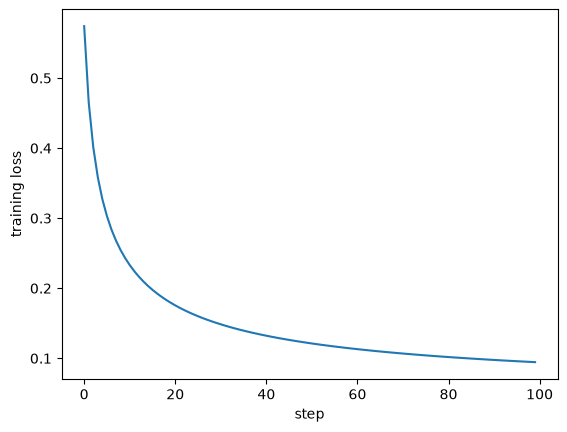

train accuracy: 0.9824175834655762
test accuracy:  0.9649122953414917


In [5]:
D = X_train.shape[1]  # number of features
y_float = y_train.float()  # the loss formula needs float labels
N = len(y_float)

w = torch.randn(D) * 0.1
w0 = torch.zeros(1)
lr = 0.1

losses = []
for step in range(100):
    p = torch.sigmoid(X_train @ w + w0)
    loss = -(y_float * torch.log(p) + (1 - y_float) * torch.log(1 - p)).mean()
    losses.append(loss.item())

    grad_w = X_train.T @ (p - y_float) / N  # gradient of the loss with respect to w
    grad_w0 = (p - y_float).mean()          # gradient of the loss with respect to w0

    ######## YOUR CODE HERE #########
    w = w - lr * grad_w
    w0 = w0 - lr * grad_w0
    #################################

plt.plot(losses)
plt.xlabel("step")
plt.ylabel("training loss")
plt.show()

train_acc = ((torch.sigmoid(X_train @ w + w0) > 0.5).long() == y_train).float().mean()
test_acc = ((torch.sigmoid(X_test @ w + w0) > 0.5).long() == y_test).float().mean()
print("train accuracy:", train_acc.item())
print("test accuracy: ", test_acc.item())

b) The network below has a hidden layer of $M = 16$ ReLU units and a sigmoid output. Backpropagation computes the gradients for all $N$ samples at once:
- output layer: $\delta^{(2)}_n = (p_n - y_n)/N$, so $\nabla_{\mathbf{w}^{(2)}}\mathcal{L} = \mathbf{Z}^\top \boldsymbol{\delta}^{(2)}$ and $\partial\mathcal{L}/\partial b_2 = \sum_n \delta^{(2)}_n$,
- hidden layer: $\delta^{(1)}_{nj} = h'(a_{nj})\, w^{(2)}_j\, \delta^{(2)}_n$, with $h'(a) = 1$ if $a > 0$ and $0$ otherwise (ReLU), so $\nabla_{\mathbf{W}^{(1)}}\mathcal{L} = (\boldsymbol{\delta}^{(1)})^\top \mathbf{X}$ and $\nabla_{\mathbf{b}_1}\mathcal{L} = \sum_n \boldsymbol{\delta}^{(1)}_n$.

In [6]:
torch.manual_seed(0)
M = 16
W1 = (torch.randn(M, D) * 0.1).requires_grad_()  # requires_grad: PyTorch computes the gradient
b1 = torch.zeros(M, requires_grad=True)
w2 = (torch.randn(M) * 0.1).requires_grad_()
b2 = torch.zeros(1, requires_grad=True)

# forward pass
A1 = X_train @ W1.T + b1         # activations of the hidden layer, a_nj: shape (N, M)
Z1 = torch.relu(A1)              # hidden units, z_nj = h(a_nj): shape (N, M)
p = torch.sigmoid(Z1 @ w2 + b2)  # predicted probabilities: shape (N,)
loss = -(y_float * torch.log(p) + (1 - y_float) * torch.log(1 - p)).mean()

# PyTorch: computes all gradients and stores them in W1.grad, b1.grad, w2.grad and b2.grad
loss.backward()

# backpropagation by hand
with torch.no_grad():
    delta2 = (p - y_float) / N                                 # output layer: shape (N,)
    grad_w2 = Z1.T @ delta2                                    # (M, N) @ (N,) -> (M,)
    grad_b2 = delta2.sum()

    delta1 = (A1 > 0).float() * delta2[:, None] * w2[None, :]  # hidden layer: reuses delta2, shape (N, M)
    grad_W1 = delta1.T @ X_train                               # (M, N) @ (N, D) -> (M, D)
    grad_b1 = delta1.sum(dim=0)                                # (M,)

print("same gradients as PyTorch:",
      torch.allclose(grad_W1, W1.grad, atol=1e-6), torch.allclose(grad_b1, b1.grad, atol=1e-6),
      torch.allclose(grad_w2, w2.grad, atol=1e-6), torch.allclose(grad_b2, b2.grad, atol=1e-6))

same gradients as PyTorch: True True True True


**Answer:** Backpropagation computes the $\delta$'s layer by layer, from the output to the input: the $\delta$ of a hidden unit is a weighted sum of the $\delta$'s of the next layer, multiplied by $h'(a)$. Every $\delta$ is computed once and then reused for all the weights that need it, just like computing Fibonacci numbers bottom-up (dynamic programming) instead of with recursion, which would compute the same numbers over and over. As a result, computing all gradients costs about as much as a forward pass, however deep the network is.

PyTorch's autograd does exactly this, automatically, for any network: it records the operations of the forward pass and goes through them backwards when we call `loss.backward()`. From now on, we let PyTorch compute the gradients.

## 2 The training loop in PyTorch

To train a network in PyTorch, we need three things:
- a **model**, for example our `HyperparameterModel`,
- a **loss function**: for multi-class classification, `nn.CrossEntropyLoss()`. Remember from PC lab 1 that it takes the **logits** as input, not probabilities.
- an **optimizer** from `torch.optim`, which updates the weights. We give it the parameters of the model and the learning rate, for example `torch.optim.SGD(model.parameters(), lr=0.1)`.

Every training step then consists of the same five lines:

```python
optimizer.zero_grad()            # 1. reset the gradients
logits = model(X_batch)          # 2. forward pass
loss = loss_fn(logits, y_batch)  # 3. compute the loss
loss.backward()                  # 4. backward pass: compute the gradients
optimizer.step()                 # 5. update the weights
```

Let's take a few steps on a single batch of MNIST images:

In [7]:
model = HyperparameterModel(dimensions_from_input_to_output=[784, 128, 10])
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

X_batch, y_batch = next(iter(train_loader))
for step in range(5):
    optimizer.zero_grad()
    loss = loss_fn(model(X_batch), y_batch)
    loss.backward()
    optimizer.step()
    print(f"step {step}: loss {loss.item():.3f}")

step 0: loss 2.297
step 1: loss 2.257
step 2: loss 2.218
step 3: loss 2.181
step 4: loss 2.143


Why do we need `optimizer.zero_grad()`? PyTorch **adds** new gradients to the ones that are already stored in `.grad`. Without resetting them, every step would use the sum of the gradients of all previous batches:

In [8]:
layer = nn.Linear(3, 1)
x = torch.ones(1, 3)

layer(x).sum().backward()
print(layer.weight.grad)

layer(x).sum().backward()  # without zero_grad, the gradients accumulate
print(layer.weight.grad)

tensor([[1., 1., 1.]])
tensor([[2., 2., 2.]])


To **evaluate** a model, we don't need gradients, and some layers (dropout and batch normalization, see below) behave differently during training and evaluation. Therefore, we:
- put the model in evaluation mode with `model.eval()` (and back in training mode with `model.train()` before training),
- wrap the evaluation in `with torch.no_grad():`, which saves memory and time.

<div class="alert alert-success">

<b>EXERCISE 2: a training loop</b>

a) Write a function `train_one_epoch(model, loader, loss_fn, optimizer)` that does one pass over the training data (one **epoch**), with a training step for every batch. Put the model in training mode first. Return a list with the loss of every batch (use `loss.item()`).

b) Write a function `evaluate(model, loader, loss_fn)` that returns the average loss and the accuracy of the model on all data in the loader. Use evaluation mode and `torch.no_grad()`.

c) Train a `HyperparameterModel` with dimensions `[784, 128, 10]` with SGD and learning rate 0.1 for 5 epochs. Print the validation loss and accuracy (using `val_loader`) before training, and after every epoch also the average training loss.

</div>

a) and b)

In [9]:
######## YOUR CODE HERE #########
def train_one_epoch(model, loader, loss_fn, optimizer):
    model.train()
    batch_losses = []
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        loss = loss_fn(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    return batch_losses


def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            total_loss += loss_fn(logits, y_batch).item() * len(y_batch)
            correct += (logits.argmax(dim=1) == y_batch).sum().item()
            n += len(y_batch)
    return total_loss / n, correct / n
#################################

c)

In [10]:
######## YOUR CODE HERE #########
model = HyperparameterModel(dimensions_from_input_to_output=[784, 128, 10])
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

val_loss, val_acc = evaluate(model, val_loader, loss_fn)
print(f"before training: val loss {val_loss:.3f}, val accuracy {val_acc:.3f}")
for epoch in range(1, 6):
    batch_losses = train_one_epoch(model, train_loader, loss_fn, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, loss_fn)
    print(f"epoch {epoch}: train loss {np.mean(batch_losses):.3f}, "
          f"val loss {val_loss:.3f}, val accuracy {val_acc:.3f}")
#################################

before training: val loss 2.313, val accuracy 0.085


epoch 1: train loss 0.482, val loss 0.276, val accuracy 0.921


epoch 2: train loss 0.250, val loss 0.217, val accuracy 0.940


epoch 3: train loss 0.195, val loss 0.181, val accuracy 0.949


epoch 4: train loss 0.158, val loss 0.153, val accuracy 0.955


epoch 5: train loss 0.133, val loss 0.133, val accuracy 0.963


Before training, the accuracy is about 10%, as in PC lab 1. After a single epoch (750 update steps), it is already about 92%, and after 5 epochs about 96%.

From now on, we use the helper function `fit` below. It does exactly what you did in c), using your `train_one_epoch` and `evaluate` functions, and records the losses and accuracies in a dictionary, the **history**. `plot_batch_losses` plots the training loss of every batch for one or more histories.

In [11]:
def fit(model, optimizer, train_loader, val_loader, n_epochs, loss_fn=None, verbose=True):
    """Train with train_one_epoch and evaluate, and record the learning curves."""
    loss_fn = loss_fn or nn.CrossEntropyLoss()
    history = {"batch_loss": [], "train_loss": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, n_epochs + 1):
        batch_losses = train_one_epoch(model, train_loader, loss_fn, optimizer)
        # the validation loss is always the plain cross-entropy, so that runs can be compared
        val_loss, val_acc = evaluate(model, val_loader, nn.CrossEntropyLoss())
        history["batch_loss"].extend(batch_losses)  # all batches of all epochs in one flat list
        history["train_loss"].append(np.mean(batch_losses))
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        if verbose:
            print(f"epoch {epoch:3d}: train loss {history['train_loss'][-1]:.3f}, "
                  f"val loss {val_loss:.3f}, val accuracy {val_acc:.3f}")
    return history


def plot_batch_losses(histories, smooth=50):
    """Plot the (smoothed) training loss of every batch, for a dictionary of histories."""
    for name, history in histories.items():
        k = min(smooth, len(history["batch_loss"]))
        plt.plot(np.convolve(history["batch_loss"], np.ones(k) / k, mode="valid"), label=name)
    plt.xlabel("training step (batch)")
    plt.ylabel("training loss (smoothed)")
    plt.legend()
    plt.show()

## 3 The learning rate

The learning rate is the most important hyperparameter of training: if it is too small, training is slow; if it is too large, the steps overshoot the minimum.

<div class="alert alert-success">

<b>EXERCISE 3: learning rate and batch size</b>

a) For every learning rate in `[0.001, 0.01, 0.1, 1.0, 3.0]`, train a new `HyperparameterModel([784, 128, 10])` for one epoch with SGD. Use `torch.manual_seed(0)` before creating every model, so that all models start from the same weights. Store the histories in a dictionary and compare the training losses with `plot_batch_losses`. <b>THINK:</b> What happens for small and for large learning rates?

b) <b>THINK:</b> The batch size determines how many samples are used to estimate the gradient in every step. With the full training set, we get "classical" gradient descent; with mini-batches, **stochastic gradient descent** (SGD). Run the cell for b): it trains a model for one epoch with batch sizes 8, 64, 512 and 48000 (the full training set). Why does full-batch gradient descent perform so badly after one epoch? Why don't we always use the smallest possible batch size?

</div>

a)

lr = 0.001: 

epoch   1: train loss 2.224, val loss 2.142, val accuracy 0.507
lr = 0.01: 

epoch   1: train loss 1.357, val loss 0.705, val accuracy 0.845
lr = 0.1: 

epoch   1: train loss 0.481, val loss 0.285, val accuracy 0.919
lr = 1.0: 

epoch   1: train loss 0.419, val loss 0.302, val accuracy 0.908
lr = 3.0: 

epoch   1: train loss 2.398, val loss 2.316, val accuracy 0.099


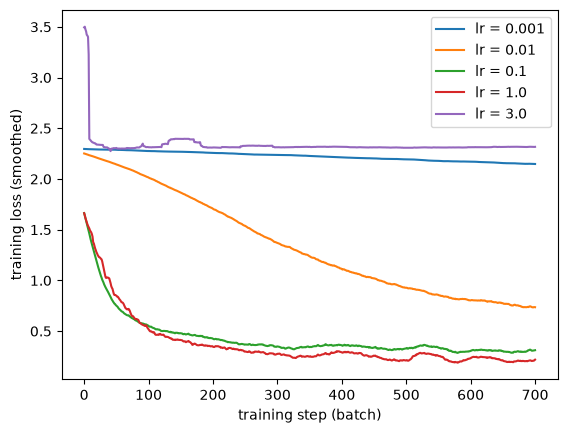

In [12]:
######## YOUR CODE HERE #########
histories = {}
for lr in [0.001, 0.01, 0.1, 1.0, 3.0]:
    torch.manual_seed(0)
    model = HyperparameterModel(dimensions_from_input_to_output=[784, 128, 10])
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    print(f"lr = {lr}:", end=" ")
    histories[f"lr = {lr}"] = fit(model, optimizer, train_loader, val_loader, n_epochs=1)

plot_batch_losses(histories)
#################################

**Answer:** With a small learning rate (0.001), the loss barely decreases in one epoch: the steps are too small. A larger learning rate trains faster: here, 0.1 and even 1.0 work well. With 3.0, the steps overshoot: the loss jumps up and the model ends at chance level (10%). Training has **diverged**. The best learning rate is often just below the point where training becomes unstable, and it has to be tuned for every model and optimizer.

b)

In [13]:
for batch_size in [8, 64, 512, 48000]:
    torch.manual_seed(0)
    model = HyperparameterModel(dimensions_from_input_to_output=[784, 128, 10])
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    loader = DataLoader(TensorDataset(X_train_mnist, y_train_mnist), batch_size=batch_size, shuffle=True)

    start = time.time()
    history = fit(model, optimizer, loader, val_loader, n_epochs=1, verbose=False)
    print(f"batch size {batch_size:5d}: {len(history['batch_loss']):4d} updates, "
          f"val accuracy {history['val_acc'][-1]:.3f}, time {time.time() - start:.1f} s")

batch size     8: 6000 updates, val accuracy 0.960, time 4.7 s


batch size    64:  750 updates, val accuracy 0.919, time 1.5 s


batch size   512:   94 updates, val accuracy 0.857, time 0.7 s


batch size 48000:    1 updates, val accuracy 0.182, time 0.7 s


**Answer:** One epoch is one pass over the training data, so the number of updates is the number of samples divided by the batch size. Full-batch gradient descent computes the exact gradient, but makes only **one** update per epoch, so after one epoch the model has barely changed. With mini-batches, every gradient is a noisy estimate, but we take many more steps per epoch, which is why SGD makes much faster progress.

The smallest batches are not always best, though: the updates become very noisy, and we cannot use the parallelism of the hardware. Computing the gradient of 512 samples at once takes hardly longer than for 8 samples, especially on a GPU, so an epoch with small batches takes much longer. In practice, batch sizes between 32 and 512 are common, and the learning rate is tuned together with the batch size. In this PC lab, we use 64.

## 4 Optimizers

Plain SGD uses the same learning rate for every parameter and every step. Two common improvements are:
- **momentum** replaces the gradient by a running average of past gradients. Oscillations cancel out, and steps in a consistent direction add up: `torch.optim.SGD(..., momentum=0.9)`.
- **adaptive learning rates** (AdaGrad, RMSprop) scale the step of every parameter by the size of its recent gradients. **Adam** combines this with momentum: `torch.optim.Adam(..., lr=1e-3)`.

<div class="alert alert-success">

<b>EXERCISE 4: comparing optimizers</b>

Train a new `HyperparameterModel([784, 128, 10])` for one epoch with each of these optimizers, and compare the training losses with `plot_batch_losses`:
- SGD with learning rate 0.01,
- SGD with learning rate 0.01 and momentum 0.9,
- Adam with learning rate 0.001.

<b>THINK:</b> Which optimizer trains fastest?

</div>

SGD: 

epoch   1: train loss 1.357, val loss 0.705, val accuracy 0.845
SGD + momentum: 

epoch   1: train loss 0.509, val loss 0.285, val accuracy 0.917
Adam: 

epoch   1: train loss 0.375, val loss 0.210, val accuracy 0.941


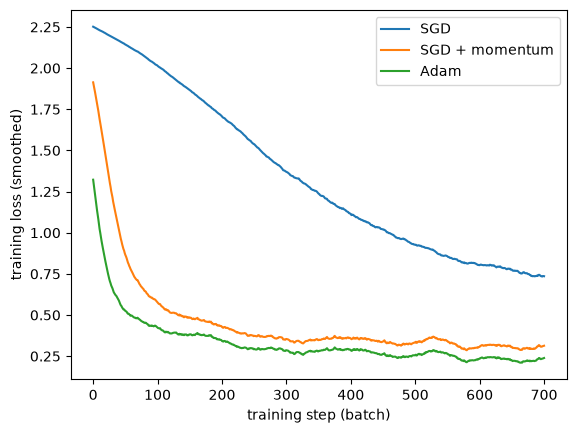

In [14]:
######## YOUR CODE HERE #########
optimizers = {
    "SGD": lambda params: torch.optim.SGD(params, lr=0.01),
    "SGD + momentum": lambda params: torch.optim.SGD(params, lr=0.01, momentum=0.9),
    "Adam": lambda params: torch.optim.Adam(params, lr=0.001),
}

histories = {}
for name, make_optimizer in optimizers.items():
    torch.manual_seed(0)
    model = HyperparameterModel(dimensions_from_input_to_output=[784, 128, 10])
    print(f"{name}:", end=" ")
    histories[name] = fit(model, make_optimizer(model.parameters()), train_loader, val_loader, n_epochs=1)

plot_batch_losses(histories)
#################################

**Answer:** With the same learning rate, momentum trains much faster than plain SGD, because consistent gradient directions add up to larger steps. Adam trains fastest, with its default learning rate of 0.001 and without any tuning. In practice, Adam (or its variant AdamW) with a learning rate around $10^{-3}$ is a robust default. SGD with momentum and a well-tuned learning rate is still common too, for example for CNNs.

To see *why* momentum and Adam help, let's look at a loss surface with only two weights, $w_1$ and $w_2$. It forms a ravine: steep in the $w_1$ direction, with the minimum far away in the $w_2$ direction. Such **pathological curvature** is common in the loss surfaces of neural networks. Run the cell below to see the path of every optimizer, starting from $(5, 5)$.

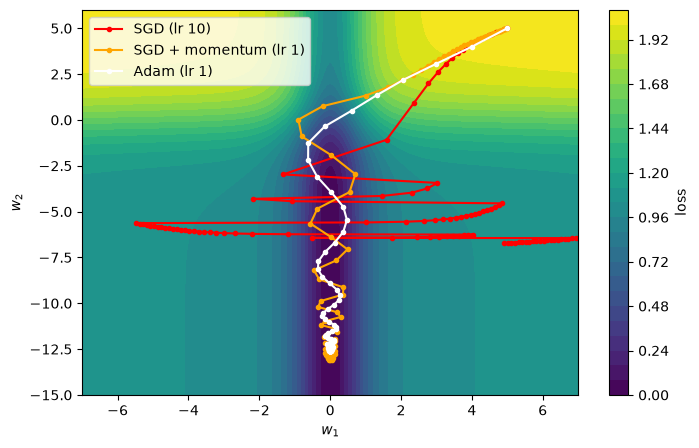

In [15]:
def pathological_curve_loss(w1, w2):
    # steep in the w1 direction, shallow in the w2 direction
    return torch.tanh(w1) ** 2 + 0.01 * torch.abs(w1) + torch.sigmoid(w2)


def train_curve(make_optimizer, n_steps=100, init=(5.0, 5.0)):
    weights = nn.Parameter(torch.tensor(init))
    optimizer = make_optimizer([weights])
    points = []
    for _ in range(n_steps):
        points.append(weights.detach().clone())
        loss = pathological_curve_loss(weights[0], weights[1])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return torch.stack(points).numpy()


paths = {
    "SGD (lr 10)": train_curve(lambda params: torch.optim.SGD(params, lr=10)),
    "SGD + momentum (lr 1)": train_curve(lambda params: torch.optim.SGD(params, lr=1, momentum=0.9)),
    "Adam (lr 1)": train_curve(lambda params: torch.optim.Adam(params, lr=1)),
}

W1, W2 = torch.meshgrid(torch.linspace(-7, 7, 200), torch.linspace(-15, 6, 200), indexing="xy")
plt.figure(figsize=(8, 5))
plt.contourf(W1.numpy(), W2.numpy(), pathological_curve_loss(W1, W2).numpy(), levels=30, cmap="viridis")
plt.colorbar(label="loss")
for (name, path), color in zip(paths.items(), ["red", "orange", "white"]):
    plt.plot(path[:, 0], path[:, 1], "o-", color=color, markersize=3, label=name)
plt.xlabel("$w_1$")
plt.ylabel("$w_2$")
plt.legend()
plt.show()

Plain SGD jumps back and forth across the steep ravine (the $w_1$ direction) and makes little progress towards the minimum along $w_2$. With momentum, the steps in the $w_1$ direction cancel out, while the steps along $w_2$ add up. Adam additionally scales the step of every weight by the size of its gradients, so both directions get a suitable step size.

(The learning rate of SGD with momentum is 10 times smaller, because PyTorch's momentum sums the past gradients: with momentum 0.9, the effective step becomes about $1/(1 - 0.9) = 10$ times larger.)

## 5 Normalization

In this section, we look at the normalization of the input data, and of the hidden layers of a network.

For the hidden layers, there are two common normalization layers. Think of the hidden activations of a mini-batch as a matrix, with one row per sample and one column per hidden unit:
- **batch normalization** (`nn.BatchNorm1d`) normalizes every **column**: every hidden unit gets mean 0 and variance 1 over the samples of the mini-batch,
- **layer normalization** (`nn.LayerNorm`) normalizes every **row**: every sample gets mean 0 and variance 1 over the hidden units of the layer.

Both then apply a learnable scale and shift, so that the network can undo the normalization where that helps.

<div class="alert alert-success">

<b>EXERCISE 5: normalization</b>

a) <b>THINK:</b> **Data normalization.** The cell for a) trains a logistic regression model (`nn.Linear(30, 1)` with `nn.BCEWithLogitsLoss()`) with 200 steps of full-batch gradient descent, on the **raw** breast cancer features with learning rates `1e-6`, `1e-4` and `1e-2`, and on the standardized features with learning rate 0.1. Run it. Can you find a learning rate that works well for the raw features? Why (not)? Hint: look at the standard deviations of the raw features.

b) **Normalizing the hidden layers.** Complete the function `deep_mlp` in the cell for b), which builds a deep network with 10 hidden layers: after every hidden linear layer (before the ReLU), add `nn.BatchNorm1d(width)` if `norm == "batch"`, or `nn.LayerNorm(width)` if `norm == "layer"`. The rest of the cell trains the network for one epoch without normalization, with batch normalization and with layer normalization. <b>THINK:</b> What happens without normalization? Why?

c) <b>THINK:</b> The cell for c) puts the same sample `x` in two different batches, and compares its output after batch and layer normalization. Why does batch normalization give a different output for `x` in batch A and in batch B, and layer normalization does not? In evaluation mode, batch normalization uses running averages of the mean and variance, which it collected during training. Why is this necessary when making predictions? What goes wrong if you forget `model.eval()`?

</div>

a)

std of the raw features: min 0.0027412232011556625 max 576.5751953125


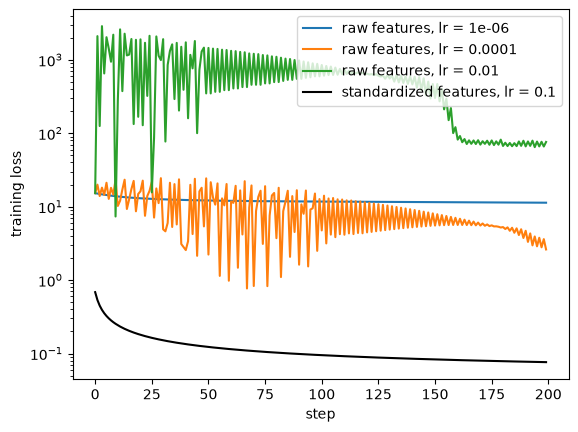

In [16]:
print("std of the raw features: min", X_train_raw.std(dim=0).min().item(),
      "max", X_train_raw.std(dim=0).max().item())

y_train_column = y_train.float().unsqueeze(1)  # BCEWithLogitsLoss needs float labels with the shape of the output


def train_logistic_regression(X, lr, n_steps=200):
    torch.manual_seed(0)
    model = nn.Linear(30, 1)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    losses = []
    for step in range(n_steps):
        optimizer.zero_grad()
        loss = loss_fn(model(X), y_train_column)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses


for lr in [1e-6, 1e-4, 1e-2]:
    plt.plot(train_logistic_regression(X_train_raw, lr), label=f"raw features, lr = {lr}")
plt.plot(train_logistic_regression(X_train, 0.1), label="standardized features, lr = 0.1", color="black")
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("training loss")
plt.legend()
plt.show()

**Answer:** No learning rate works well for the raw features. Their standard deviations range from about 0.003 to almost 600: five orders of magnitude. The gradient of every weight scales with its feature, so the loss surface is an extremely elongated ravine (like in section 4). A learning rate that is small enough for the large features (1e-6) is far too small for the others, and training crawls; a larger learning rate makes the loss explode or oscillate. After standardization, all directions have a similar scale and one learning rate works for all of them. So always standardize the input features (with the statistics of the training set).

b)

normalization = None: 

epoch   1: train loss 2.302, val loss 2.302, val accuracy 0.109
normalization = batch: 

epoch   1: train loss 0.603, val loss 0.188, val accuracy 0.952
normalization = layer: 

epoch   1: train loss 0.490, val loss 0.203, val accuracy 0.945


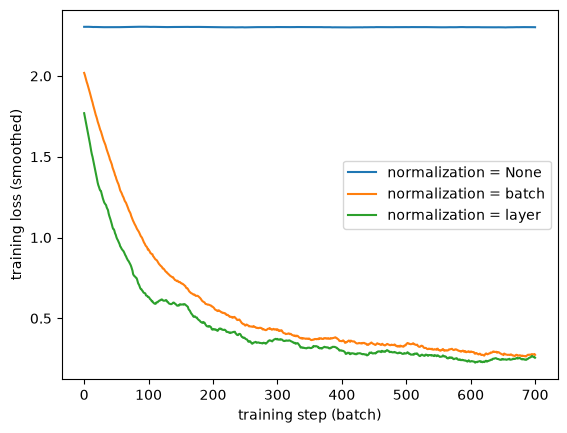

In [17]:
def deep_mlp(norm=None, n_hidden_layers=10, width=128):
    layers, d_in = [], 784
    for _ in range(n_hidden_layers):
        layers.append(nn.Linear(d_in, width))
        ######## YOUR CODE HERE #########
        if norm == "batch":
            layers.append(nn.BatchNorm1d(width))
        elif norm == "layer":
            layers.append(nn.LayerNorm(width))
        #################################
        layers.append(nn.ReLU())
        d_in = width
    layers.append(nn.Linear(width, 10))
    return nn.Sequential(*layers)


histories_deep = {}
for norm in [None, "batch", "layer"]:
    torch.manual_seed(0)
    model = deep_mlp(norm)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    print(f"normalization = {norm}:", end=" ")
    histories_deep[f"normalization = {norm}"] = fit(model, optimizer, train_loader, val_loader, n_epochs=1)

plot_batch_losses(histories_deep)

**Answer:** Without normalization, the loss stays at $\ln(10) \approx 2.30$ and the accuracy at chance level (11%): the deep network does not learn at all. Through 10 layers, the activations and the gradients shrink, so that the first layers hardly receive any useful gradient (**vanishing gradients**). With batch normalization (95%) or layer normalization (94.5%), the input of every layer is normalized again, the signal keeps a healthy scale, and the same network trains without problems. Both work here; question c) shows how they differ. (A careful initialization of the weights, such as He/Kaiming initialization, and residual connections also help to train deep networks.)

c)

In [18]:
torch.manual_seed(0)
batchnorm, layernorm = nn.BatchNorm1d(4), nn.LayerNorm(4)

x = torch.randn(1, 4)                                # one sample with 4 hidden units
batch_a = torch.cat([x, torch.randn(7, 4)])          # x together with 7 other samples
batch_b = torch.cat([x, torch.randn(7, 4) * 5 + 3])  # x together with 7 very different samples

with torch.no_grad():
    print("training mode, output for x:")
    print("  batch norm, in batch A:", batchnorm(batch_a)[0])
    print("  batch norm, in batch B:", batchnorm(batch_b)[0])
    print("  layer norm, in batch A:", layernorm(batch_a)[0])
    print("  layer norm, in batch B:", layernorm(batch_b)[0])

    batchnorm.eval()
    print("evaluation mode, output for x:")
    print("  batch norm, in batch A:", batchnorm(batch_a)[0])
    print("  batch norm, in batch B:", batchnorm(batch_b)[0])
    print("  batch norm, x alone:   ", batchnorm(x)[0])

training mode, output for x:
  batch norm, in batch A: tensor([ 1.6231, -0.4260, -1.6760,  0.5304])
  batch norm, in batch B: tensor([ 0.0103, -0.4909, -0.8171, -0.8370])
  layer norm, in batch A: tensor([ 1.1918, -0.1481, -1.5251,  0.4814])
  layer norm, in batch B: tensor([ 1.1918, -0.1481, -1.5251,  0.4814])
evaluation mode, output for x:
  batch norm, in batch A: tensor([ 0.9244, -0.2640, -1.1158,  0.2643])
  batch norm, in batch B: tensor([ 0.9244, -0.2640, -1.1158,  0.2643])
  batch norm, x alone:    tensor([ 0.9244, -0.2640, -1.1158,  0.2643])


**Answer:** Batch normalization normalizes every hidden unit with the mean and variance **of the current batch**, so the output for `x` depends on which other samples happen to be in the batch. Layer normalization only uses the values of `x` itself, so its output is the same in any batch.

When making predictions, the output for a sample should not depend on the other samples in the batch, and we may want to predict a single sample (in training mode, batch normalization even gives an error for a batch of one sample: the variance of one value cannot be computed). Therefore, batch normalization keeps running averages of the mean and variance during training, and uses those in evaluation mode: then the output for `x` is the same in every batch, and also on its own. If you forget `model.eval()`, the predictions depend on the batch, and can be very wrong for small batches. Dropout (part 2) also behaves differently in evaluation mode.

Layer normalization behaves the same during training and evaluation, and works for any batch size. That is why it is used in transformers and recurrent networks, while batch normalization is common in CNNs and MLPs trained with reasonably large batches.

---
*This is the end of part 1. In part 2, we look at what happens when a large network is trained on a small dataset.*

---

# Part 2: Regularization

## 6 Overfitting

In bioinformatics, datasets are often small, and labels are often noisy: annotations contain mistakes and diagnoses can be uncertain. We simulate this with MNIST: we keep only **1000 training images**, and replace **20% of their labels** with a random digit. The validation set (2000 images, to keep training fast) has the correct labels.

We train a large network ($784 \to 512 \to 512 \to 10$, about 670,000 parameters) with Adam for 50 epochs. The function `new_model` creates this network, with the same initial weights every time (unless you change its `seed`), so that we can compare runs. `plot_histories` plots the learning curves of one or more runs, and the dictionary `results` collects the final validation accuracy of every run.

In [19]:
torch.manual_seed(0)
X_small, y_small = X_train_mnist[:1000], y_train_mnist[:1000].clone()
noisy = torch.rand(len(y_small)) < 0.2
y_small[noisy] = torch.randint(0, 10, (int(noisy.sum()),))
print("fraction of wrong labels:", (y_small != y_train_mnist[:1000]).float().mean().item())

small_train_loader = DataLoader(TensorDataset(X_small, y_small), batch_size=32, shuffle=True)
X_val_small, y_val_small = X_val_mnist[:2000], y_val_mnist[:2000]
small_val_loader = DataLoader(TensorDataset(X_val_small, y_val_small), batch_size=1000, shuffle=False)


def new_model(dropout=0.0, seed=0):
    """A large MLP. With the same seed, it starts from the same initial weights."""
    torch.manual_seed(seed)
    return HyperparameterModel(dimensions_from_input_to_output=[784, 512, 512, 10], dropout=dropout)


def plot_histories(histories):
    """Plot the training loss, validation loss and validation accuracy per epoch."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for name, history in histories.items():
        epochs = np.arange(1, len(history["train_loss"]) + 1)
        axes[0].plot(epochs, history["train_loss"], label=name)
        axes[1].plot(epochs, history["val_loss"], label=name)
        axes[2].plot(epochs, history["val_acc"], label=name)
    for ax, title in zip(axes, ["training loss", "validation loss", "validation accuracy"]):
        ax.set_title(title)
        ax.set_xlabel("epoch")
    axes[0].legend()
    plt.show()


results = {}  # validation accuracy of the final model of every run

fraction of wrong labels: 0.17900000512599945


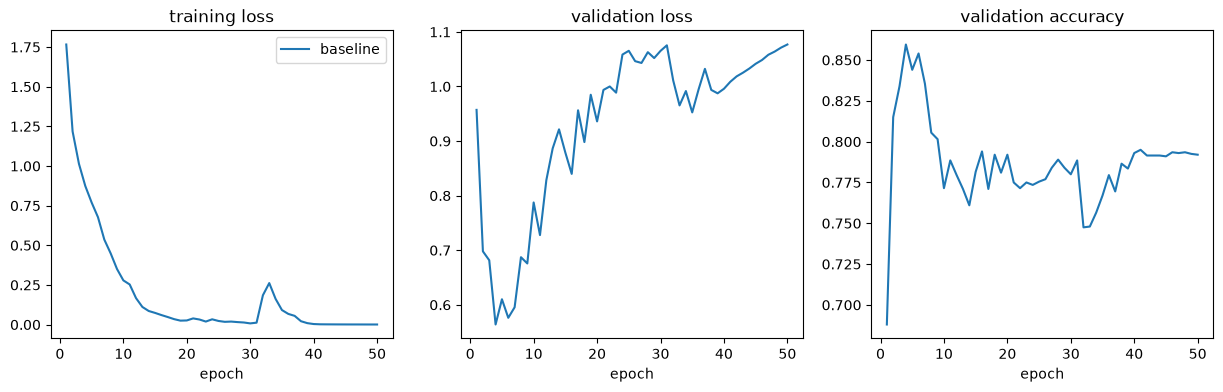

best validation accuracy: 0.860 (epoch 4), after 50 epochs: 0.792


In [20]:
model_baseline = new_model()
optimizer = torch.optim.Adam(model_baseline.parameters(), lr=1e-3)
history_baseline = fit(model_baseline, optimizer, small_train_loader, small_val_loader, n_epochs=50, verbose=False)
results["baseline"] = history_baseline["val_acc"][-1]

plot_histories({"baseline": history_baseline})
best_epoch = int(np.argmax(history_baseline["val_acc"])) + 1
print(f"best validation accuracy: {max(history_baseline['val_acc']):.3f} (epoch {best_epoch}), "
      f"after 50 epochs: {results['baseline']:.3f}")

<div class="alert alert-success">

<b>EXERCISE 6: overfitting and early stopping</b>

a) <b>THINK:</b> Describe the three curves. When does the model start to overfit? What is the model learning after that point?

b) The simplest and most widely used remedy is **early stopping**: keep the model of the epoch with the best validation loss. Write a function `fit_early_stopping(model, optimizer, train_loader, val_loader, n_epochs, patience)` that works like `fit` (without printing), but after every epoch:
- keeps a copy of the weights with the lowest validation loss so far, with `copy.deepcopy(model.state_dict())`,
- stops training when the validation loss has not improved for `patience` epochs.

At the end, load the best weights back into the model with `model.load_state_dict(...)`, and return the history. Train a new model with Adam (learning rate 0.001), at most 50 epochs and patience 5. Store the validation accuracy of the restored model in `results["early stopping"]`, and compare it with the baseline.

</div>

a)

**Answer:** The training loss goes to almost 0: the network fits every training image, including the 20% with a wrong label. It has enough parameters to simply **memorize** the training set. The validation loss is lowest after a few epochs and then rises, and the validation accuracy peaks around the same time and then drops. From that point on, the model is mostly learning the noise in the training set (the wrong labels) instead of patterns that generalize: it **overfits**. The validation loss rises faster than the accuracy drops, because the model also becomes more and more confident about its wrong predictions.

Note that all these decisions are based on the validation set. The test set is only used once, at the very end (Exercise 8).

b)

In [21]:
######## YOUR CODE HERE #########
def fit_early_stopping(model, optimizer, train_loader, val_loader, n_epochs, patience):
    loss_fn = nn.CrossEntropyLoss()
    history = {"batch_loss": [], "train_loss": [], "val_loss": [], "val_acc": []}
    best_val_loss, best_epoch, best_state = float("inf"), 0, None

    for epoch in range(1, n_epochs + 1):
        batch_losses = train_one_epoch(model, train_loader, loss_fn, optimizer)
        val_loss, val_acc = evaluate(model, val_loader, loss_fn)
        history["batch_loss"].extend(batch_losses)
        history["train_loss"].append(np.mean(batch_losses))
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss, best_epoch = val_loss, epoch
            best_state = copy.deepcopy(model.state_dict())
        elif epoch - best_epoch >= patience:
            break

    model.load_state_dict(best_state)
    return history


model = new_model()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
history_early_stopping = fit_early_stopping(model, optimizer, small_train_loader, small_val_loader,
                                            n_epochs=50, patience=5)
best_epoch = int(np.argmin(history_early_stopping["val_loss"])) + 1
print(f"trained {len(history_early_stopping['val_loss'])} epochs, restored the weights of epoch {best_epoch}")

val_loss, val_acc = evaluate(model, small_val_loader, nn.CrossEntropyLoss())
results["early stopping"] = val_acc
print(f"validation accuracy: early stopping {val_acc:.3f}, baseline {results['baseline']:.3f}")
#################################

trained 9 epochs, restored the weights of epoch 4
validation accuracy: early stopping 0.860, baseline 0.792


## 7 Dropout

**Dropout** randomly sets a fraction $p$ of the hidden units to zero in every training step, with a new random selection every time. The network cannot rely on any single unit, which forces it to learn more robust, redundant features. Dropout is only active during training: in evaluation mode, all units are used.

<div class="alert alert-success">

<b>EXERCISE 7: dropout</b>

a) <b>THINK:</b> Run the cell for a). Why are the values that are kept equal to 2 instead of 1? What happens in evaluation mode?

b) Train a new model with dropout probability 0.5 (`new_model(dropout=0.5)`) with Adam (learning rate 0.001) for 50 epochs. Compare the learning curves with the baseline, and store the final validation accuracy in `results["dropout"]`.

</div>

a)

In [22]:
dropout = nn.Dropout(p=0.5)
x = torch.ones(1, 10)

dropout.train()
print(dropout(x))
print(dropout(x))

dropout.eval()
print(dropout(x))

tensor([[2., 0., 2., 0., 0., 0., 2., 0., 0., 0.]])
tensor([[2., 2., 2., 0., 0., 0., 2., 0., 2., 2.]])
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])


**Answer:** In training mode, every value is set to 0 with probability 0.5, with a new random selection at every call. The values that are kept are scaled by $1/(1-p) = 2$, so that the expected value of every output stays the same as without dropout (here, 1). Thanks to this scaling, nothing has to change at prediction time: in evaluation mode, dropout simply does nothing, and the predictions are deterministic. This is another reason never to forget `model.eval()`.

b)

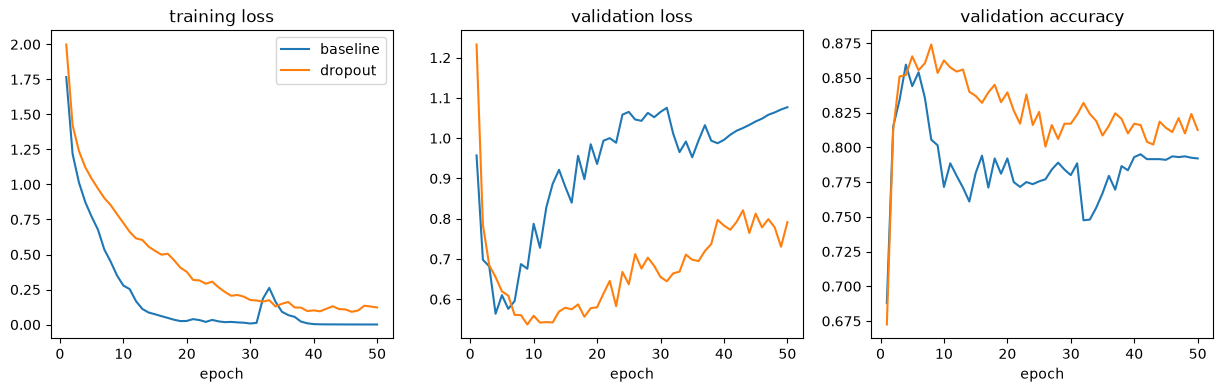

In [23]:
######## YOUR CODE HERE #########
model = new_model(dropout=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
history_dropout = fit(model, optimizer, small_train_loader, small_val_loader, n_epochs=50, verbose=False)
results["dropout"] = history_dropout["val_acc"][-1]

plot_histories({"baseline": history_baseline, "dropout": history_dropout})
#################################

**Answer:** Dropout reduces overfitting, but does not prevent it. The training loss no longer goes to 0 (0.12 after 50 epochs), the best validation accuracy is higher (87.4% instead of 86.0%), and the validation loss rises less (0.79 instead of 1.08 after 50 epochs). After 50 epochs, the model still overfits (81.2%), so in practice, dropout is combined with early stopping.

## 8 Hyperparameter optimization

We have now seen many hyperparameters: the width of the layers, the dropout rate, the learning rate, ... Another common one is the **weight decay**: a penalty that pulls all weights towards zero (see Extra 1). Roughly in order of importance, the hyperparameters of a neural network are: the number of epochs (handled by early stopping), the number of layers and their dimension, the regularization parameters and dropout rate, the learning rate, and other settings of the optimizer.

Trying every combination (**grid search**) quickly becomes too expensive. **Random search** samples random combinations instead. With the same budget, it tries many more different values of every single hyperparameter, which matters because usually only a few hyperparameters have a large effect. Smarter methods use the results so far to choose the next combination (**Bayesian optimization**), or stop unpromising runs early (**multi-fidelity optimization**).

The function `train_config` below trains a model for one combination of hyperparameters (a **configuration**), with AdamW and early stopping, and returns the model and its validation accuracy.

In [24]:
search_space = {
    "width": [256, 512, 1024],
    "dropout": [0.0, 0.2, 0.5],
    "weight_decay": [0.0, 0.01, 0.1],
    "lr": [3e-4, 1e-3, 3e-3],
}


def train_config(config, seed=0):
    """Train the MLP with one configuration of hyperparameters; return the model and its validation accuracy."""
    torch.manual_seed(seed)
    model = HyperparameterModel([784, config["width"], config["width"], 10], dropout=config["dropout"])
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    fit_early_stopping(model, optimizer, small_train_loader, small_val_loader, n_epochs=50, patience=5)
    val_loss, val_acc = evaluate(model, small_val_loader, nn.CrossEntropyLoss())
    return model, val_acc

<div class="alert alert-success">

<b>EXERCISE 8: hyperparameter optimization</b>

a) **Random search.** Create a random number generator with `rng = random.Random(0)`, and sample 6 random configurations: for every hyperparameter in `search_space`, pick a value with `rng.choice(...)`. Train every configuration with `train_config`, print the configuration and its validation accuracy, and keep the best model and configuration. Store the best validation accuracy in `results["random search"]`, and print all results, sorted from low to high.

b) Your final model is the best model of the random search. Only now, evaluate it **once** on the test set (`test_loader`).

c) <b>THINK:</b> Why do we use the validation set, and not the test set, to choose between all these models? Why is the validation accuracy of the best configuration a bit optimistic?

</div>

a)

In [25]:
######## YOUR CODE HERE #########
rng = random.Random(0)
best_acc, best_model, best_config = 0.0, None, None
for trial in range(6):
    config = {name: rng.choice(values) for name, values in search_space.items()}
    model, val_acc = train_config(config)
    print(f"trial {trial}: {config} -> validation accuracy {val_acc:.3f}")
    if val_acc > best_acc:
        best_acc, best_model, best_config = val_acc, model, config

results["random search"] = best_acc
print("\nbest configuration:", best_config, "\n")
for name, acc in sorted(results.items(), key=lambda item: item[1]):
    print(f"{name:20s} {acc:.3f}")
#################################

trial 0: {'width': 512, 'dropout': 0.2, 'weight_decay': 0.0, 'lr': 0.001} -> validation accuracy 0.842


trial 1: {'width': 1024, 'dropout': 0.2, 'weight_decay': 0.01, 'lr': 0.001} -> validation accuracy 0.854


trial 2: {'width': 512, 'dropout': 0.2, 'weight_decay': 0.1, 'lr': 0.0003} -> validation accuracy 0.859


trial 3: {'width': 1024, 'dropout': 0.0, 'weight_decay': 0.01, 'lr': 0.0003} -> validation accuracy 0.836


trial 4: {'width': 256, 'dropout': 0.5, 'weight_decay': 0.01, 'lr': 0.003} -> validation accuracy 0.861


trial 5: {'width': 1024, 'dropout': 0.5, 'weight_decay': 0.0, 'lr': 0.001} -> validation accuracy 0.865

best configuration: {'width': 1024, 'dropout': 0.5, 'weight_decay': 0.0, 'lr': 0.001} 

baseline             0.792
dropout              0.812
early stopping       0.860
random search        0.865


b)

In [26]:
######## YOUR CODE HERE #########
test_loss, test_acc = evaluate(best_model, test_loader, nn.CrossEntropyLoss())
print(f"test accuracy of the final model: {test_acc:.3f}")
#################################

test accuracy of the final model: 0.873


c)

**Answer:** Every time we compare models and keep the best one, we make a decision based on the validation set. Among 6 configurations (and all the runs before), some score high partly by chance, on this particular validation set, so the validation accuracy of the winner is a bit optimistic. If we made these choices with the test set, the test accuracy would no longer be an honest estimate of the performance on new data: the same kind of leakage as in PC lab 1, Exercise 1. Here, the test accuracy of the final model (87.3%) is close to its validation accuracy (86.5%).

Note that the best configuration is only slightly better than early stopping alone (86.0%): with 1000 noisy training images, tuning these hyperparameters helps little. Larger gains come from more data, or from data augmentation (Extra 2).

### Optional extra exercises

For when you have time left.

### Extra 1: weight decay

**Weight decay** adds a penalty $\lambda \sum w^2$ to the loss, as in ridge regression. In every step, it pulls all weights a bit towards zero, which favors smoother functions. In PyTorch, it is an argument of the optimizer: `weight_decay` (this is $\lambda$).

A practical detail: in `torch.optim.Adam`, the weight decay is added to the gradient, which Adam then rescales with its adaptive learning rate. As a result, weights with large gradients are barely regularized. `torch.optim.AdamW` applies the weight decay directly to the weights instead ("decoupled" weight decay). In practice, use **AdamW** when you want weight decay with Adam.

The cell below trains the network with `AdamW` and weight decay 0.1, and compares the size of its weights ($\sum w^2$ over all weight matrices) with the baseline.

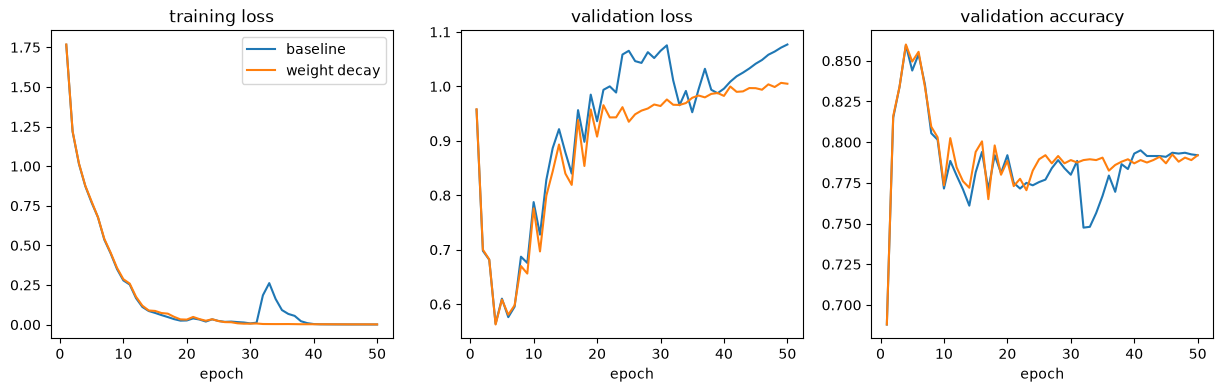

sum of squared weights: baseline 1338, weight decay 873


In [27]:
model_weight_decay = new_model()
optimizer = torch.optim.AdamW(model_weight_decay.parameters(), lr=1e-3, weight_decay=0.1)
history_weight_decay = fit(model_weight_decay, optimizer, small_train_loader, small_val_loader,
                           n_epochs=50, verbose=False)
plot_histories({"baseline": history_baseline, "weight decay": history_weight_decay})


def sum_squared_weights(model):
    return sum((p ** 2).sum().item() for name, p in model.named_parameters() if "weight" in name)


print(f"sum of squared weights: baseline {sum_squared_weights(model_baseline):.0f}, "
      f"weight decay {sum_squared_weights(model_weight_decay):.0f}")

<div class="alert alert-success">

<b>EXTRA 1 (THINK): weight decay</b>

a) What does weight decay change, and how much does it help here?

b) What is the crucial difference between L1 regularization ($\lambda \sum |w|$) and L2 regularization ($\lambda \sum w^2$)? When would you use L1?

</div>

a)

**Answer:** Weight decay clearly makes the weights smaller: the sum of the squared weights drops by about a third (from about 1340 to about 870). The final validation loss is a bit lower (1.01 instead of 1.08), but the validation accuracy is exactly the same as for the baseline (79.2%), and the training loss still goes to almost 0: the model still memorizes the noisy labels. Here, weight decay alone does not prevent overfitting. That is typical: in practice, a small weight decay (with AdamW, often between 0.01 and 0.1) is a common default that helps a little, but it is rarely the main remedy. Larger values can make training unstable, so $\lambda$ is tuned on the validation set.

b)

**Answer:** L2 regularization pulls every weight towards zero with a force proportional to its size: large weights are pulled hard, small weights hardly at all, so the weights become small but rarely exactly zero. L1 regularization pulls every weight towards zero with the same force, whatever its size, so many weights become **exactly zero**: the model becomes sparse. Use L1 when you want the model to use only a small subset of the inputs, for example a few genes out of thousands (as in the lasso). In deep learning, L2 weight decay is by far the most common.

### Extra 2: data augmentation

The best remedy for overfitting is more data. **Data augmentation** creates new training samples by transforming the existing ones in ways that do not change the label: for images, for example, small rotations and shifts. For DNA sequences, the reverse complement is a common augmentation (PC lab 3). Every epoch, the network sees a slightly different version of every image, which makes it much harder to memorize the training set.

We apply the transformation in a custom `Dataset`, every time a sample is loaded. The transformation below rotates an image by up to 10 degrees and shifts it by up to 10% in every direction.

In [28]:
from torchvision.transforms import v2

augment = v2.RandomAffine(degrees=10, translate=(0.1, 0.1))

<div class="alert alert-success">

<b>EXTRA 2: data augmentation</b>

a) Complete `__getitem__` of the `AugmentedDataset` below: reshape image `i` to shape `(1, 28, 28)`, apply the transformation, and flatten it back to 784 features. Return the image and its label. Then run the next cell to visualize 8 augmented versions of the first training image.

b) Train a new model with Adam (learning rate 0.001) for 50 epochs on the augmented training data, using `augmented_loader` (given in the cell for b). Compare the learning curves with the baseline, and print its final validation accuracy. <b>THINK:</b> What happens to the training loss, and why?

</div>

a)

In [29]:
class AugmentedDataset(Dataset):
    """A dataset that applies a random transformation every time a sample is loaded."""

    def __init__(self, X, y, transform):
        self.X, self.y, self.transform = X, y, transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        ######## YOUR CODE HERE #########
        image = self.X[i].reshape(1, 28, 28)
        image = self.transform(image)
        return image.reshape(-1), self.y[i]
        #################################

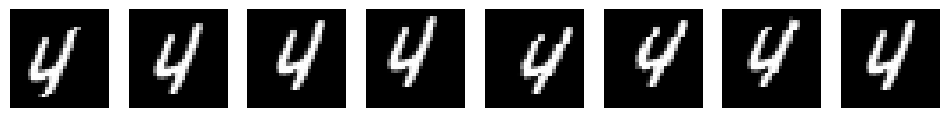

In [30]:
augmented_dataset = AugmentedDataset(X_small, y_small, augment)

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax in axes:
    image, label = augmented_dataset[0]
    ax.imshow(image.reshape(28, 28), cmap="gray")
    ax.axis("off")
plt.show()

b)

validation accuracy after 50 epochs: 0.875 (baseline: 0.792)


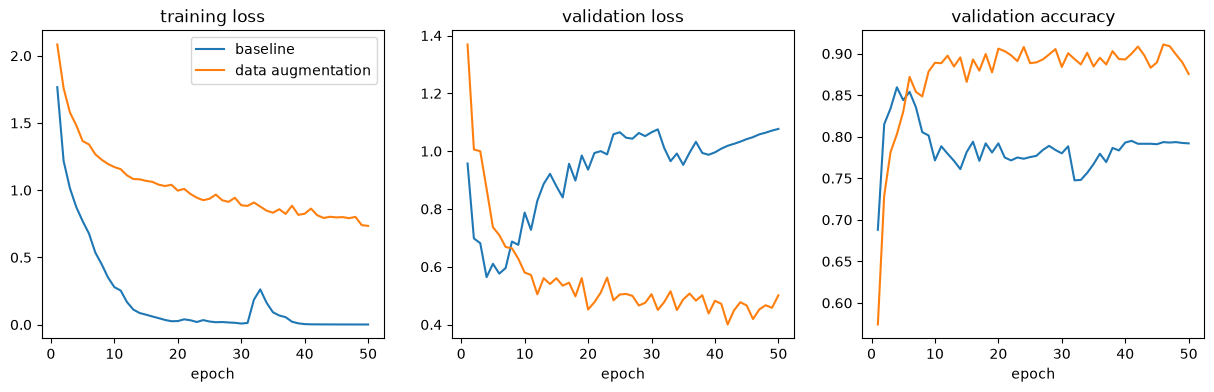

In [31]:
augmented_loader = DataLoader(augmented_dataset, batch_size=32, shuffle=True)

######## YOUR CODE HERE #########
model = new_model()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
history_augmentation = fit(model, optimizer, augmented_loader, small_val_loader, n_epochs=50, verbose=False)
print(f"validation accuracy after 50 epochs: {history_augmentation['val_acc'][-1]:.3f} (baseline: {results['baseline']:.3f})")

plot_histories({"baseline": history_baseline, "data augmentation": history_augmentation})
#################################

**Answer:** The training loss stays high (about 0.73 instead of almost 0): every epoch, the network sees new versions of the images, so it can no longer memorize them, including the wrong labels. The validation loss keeps decreasing for about 40 epochs, and the validation accuracy goes up to about 90% (87.5% after 50 epochs; it fluctuates a bit). This makes data augmentation by far the best single regularizer here. It adds knowledge about the problem (a slightly rotated or shifted digit is still the same digit), which is why it works so well. The transformations must not change the label, though: rotating a 6 by 180 degrees would turn it into a 9.

In other words, data augmentation builds an **invariance** into the model: the prediction should not change when the image is shifted or rotated a little. Another way to build in invariances is the architecture of the network itself, as convolutional networks do (PC lab 3).